In [1]:
### Plotting the analytic solution G(t, U, iw_n) and G(t(U), U, iw_n)
import numpy as np
import matplotlib.pyplot as plt
import utilities as ut
import itertools as it
import pickle
from pydlr import dlr
import cvxpy as cp
import SCE as sce
import WCE as wce

In [2]:
beta = 50.0
Ntau = 401
Ns = 4
Nw = 400
Mat_fre = (2*np.linspace(0, Nw-1, Nw)+1)*np.pi/beta
wn = np.append(-np.flip(Mat_fre),Mat_fre)   # w_n = (2n+1)*pi/beta

In [12]:
### Saving and Loading ED and MBPT data 
t_values_ED = np.around(np.linspace(0,2,21), decimals=1)
U_values_ED = 1+0*t_values_ED
print("ED t is :\n", t_values_ED)

full_sigma = "False"
data_directory_ED = '/global/cfs/cdirs/m1027/Yuan/EDLib_data/1d_hubbard/U1_t_var/'
data_directory_saving = 'ED_data'
ut.Saving_data_ED(Ns, t_values_ED , U_values_ED, Ntau, data_directory_ED, data_directory_saving, full_sigma, beta)
Gij_tau_ED, Gij_iwn_ED, Gk_tau_ED, Gk_iwn_ED  = ut.load_data_training_G_ED(data_directory_saving, Ns, beta)

print(Gij_tau_ED.shape)
print("For Ns=%d, Gij_tau_ED has the dimensionality len(U_values)*Ntau*Ns*Ns=%d*%d*%d*%d" %(Ns, Gij_tau_ED.shape[0], Gij_tau_ED.shape[1], Gij_tau_ED.shape[2], Gij_tau_ED.shape[3]))
print("For Ns=%d, Gij_iwn_ED has the dimensionality len(U_values)*Nw*Ns*Ns=%d*%d*%d*%d" %(Ns, Gij_iwn_ED.shape[0], Gij_iwn_ED.shape[1], Gij_iwn_ED.shape[2], Gij_iwn_ED.shape[3]))
        

ED t is :
 [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7
 1.8 1.9 2. ]
(21, 401, 4, 4)
For Ns=4, Gij_tau_ED has the dimensionality len(U_values)*Ntau*Ns*Ns=21*401*4*4
For Ns=4, Gij_iwn_ED has the dimensionality len(U_values)*Nw*Ns*Ns=21*800*4*4


In [15]:
t_values_wce = np.linspace(0,2,21)
t_values_sce = np.linspace(0,2,21)
Gij_iwn_wce = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_sce = np.zeros((len(t_values_sce), wn.size, Ns, Ns), dtype ='complex')
Gij_iwn_hf = np.zeros((len(t_values_wce), wn.size, Ns, Ns), dtype ='complex')
for t in range(t_values_sce.size):
    Gij_iwn_sce[t]= sce.Gij_sce_t(2, Ns, 1.0, wn, -t_values_sce[t])
for t in range(t_values_wce.size):
    Gij_iwn_hf[t], _ = wce.HF_G0(-t_values_wce[t], Ns, wn)
    Gij_iwn_wce[t]= wce.Gij_wce_U(2, Ns, 1.0, wn, beta, -t_values_wce[t])

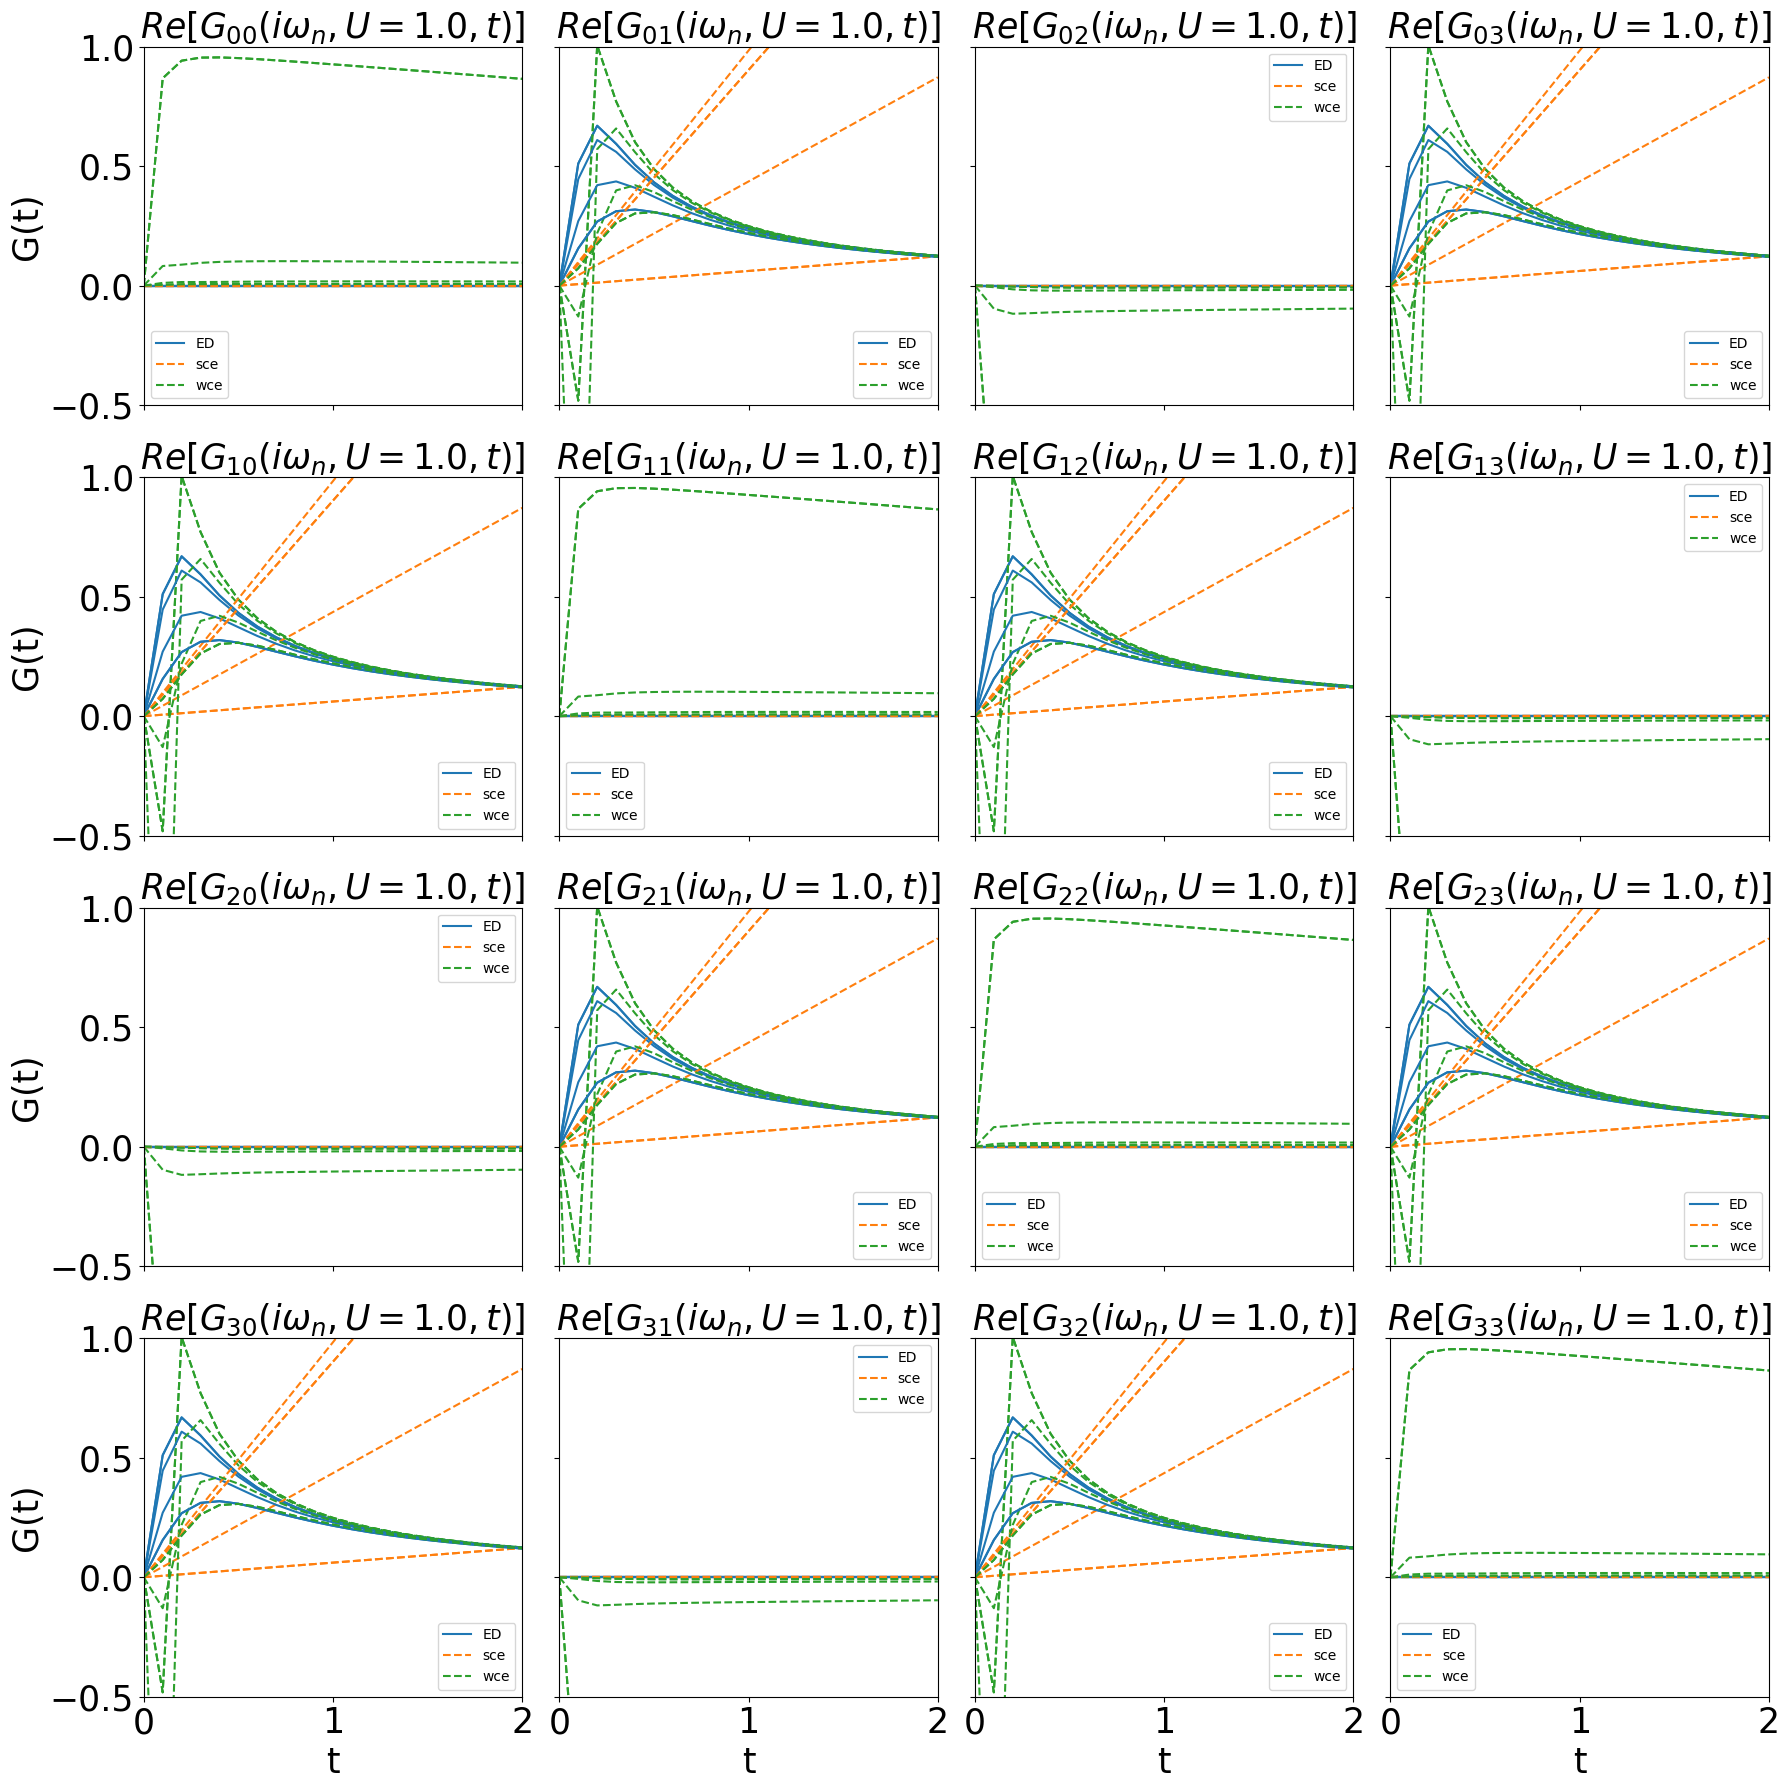

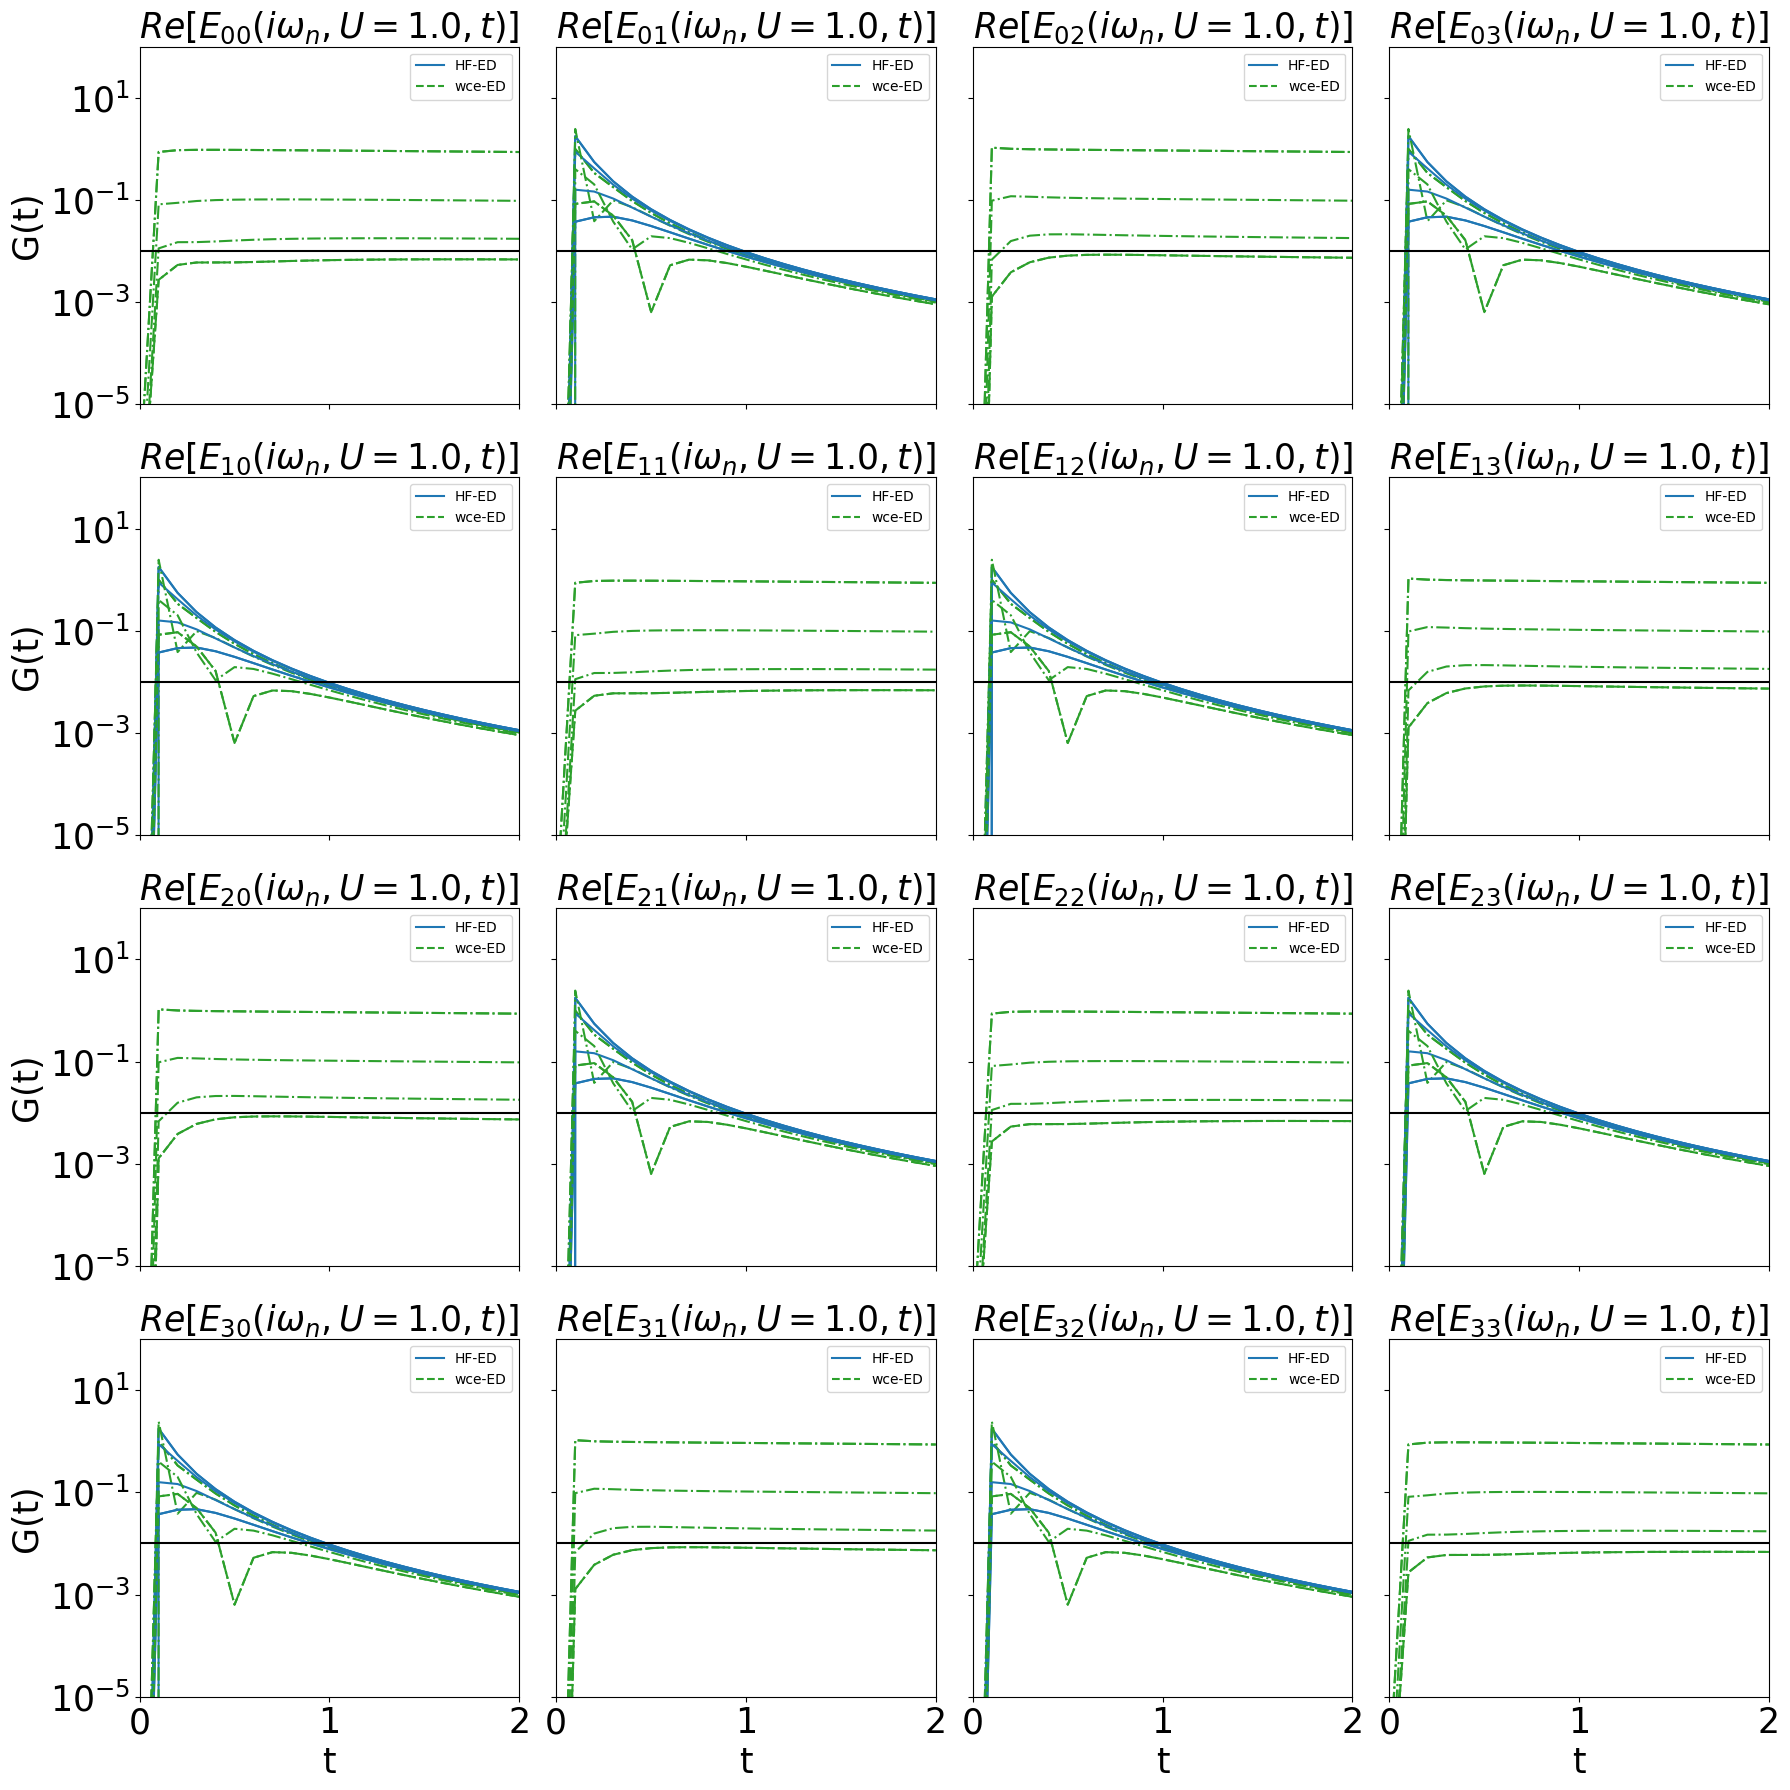

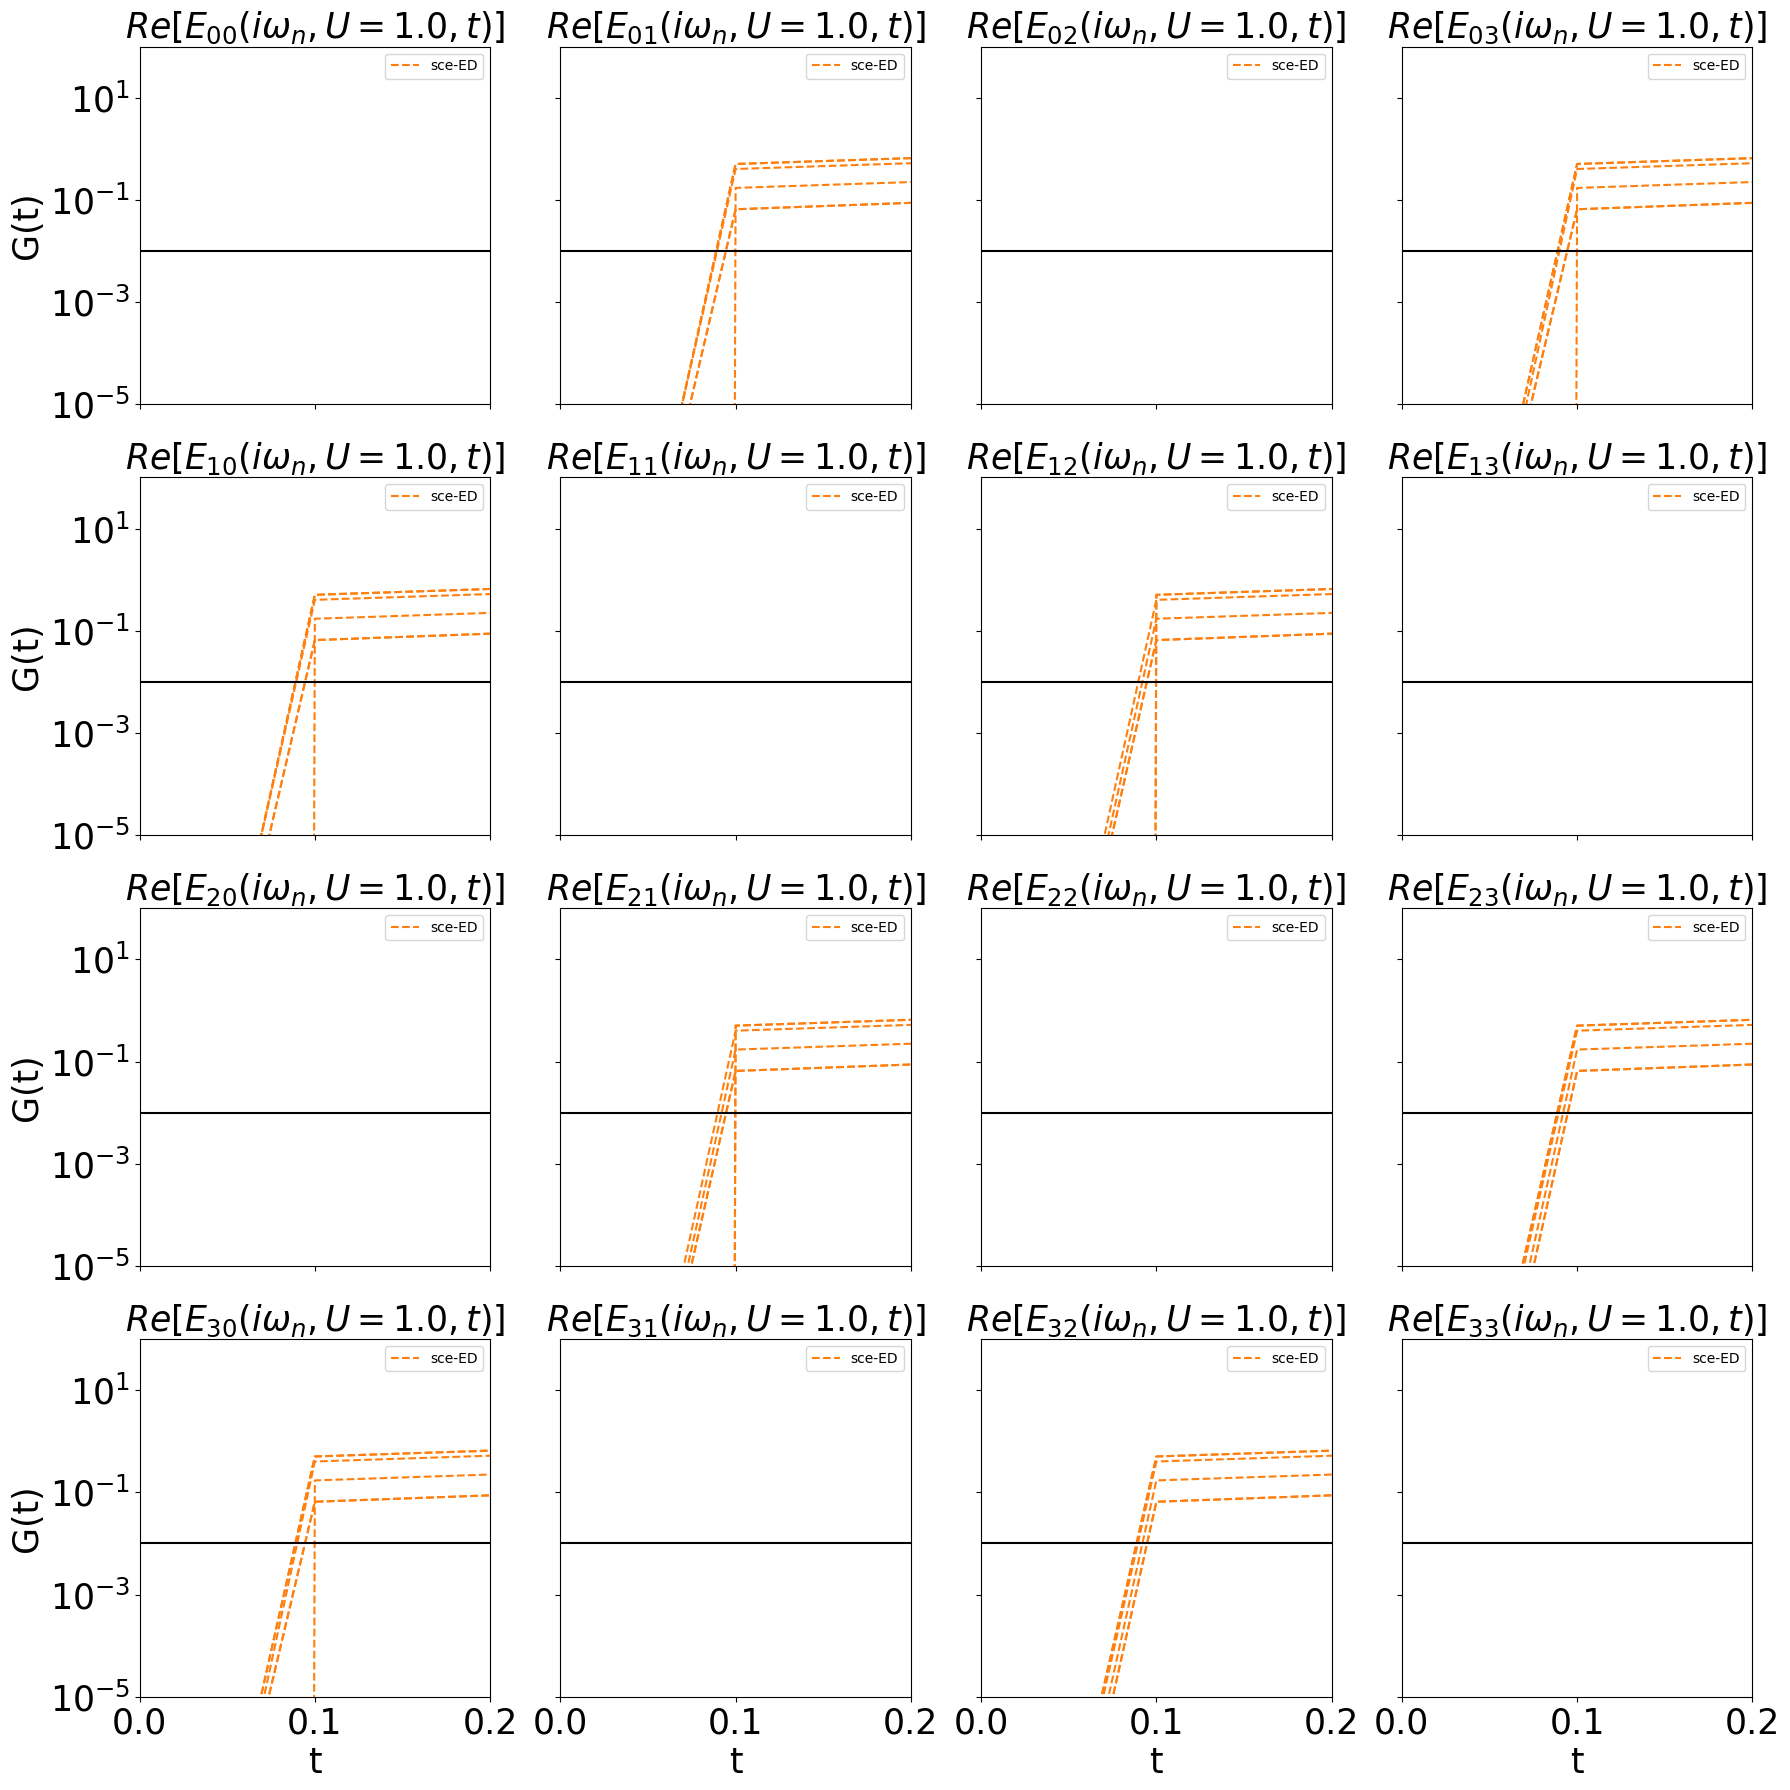

In [31]:
wn_id = [Nw, Nw-1, Nw-2, Nw-4, Nw-6]
fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            ax.plot(t_values_ED, Gij_iwn_ED[:, k, i ,j ].real, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--')

        ax.plot(t_values_ED, Gij_iwn_ED[:, k, i ,j ].real, 'C0', label = 'ED')
        ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].real, 'C1--', label = 'sce')
        ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].real, 'C2--', label = 'wce')
        ax.set_title(r'$Re[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.legend()
        ax.tick_params(labelsize=25)

        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-0.5,1])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()





fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_hf[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C0')
            # ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].real-Gij_iwn_hf[:, k, i ,j ].real), 'C1--')
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C2-.')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_hf[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C0', label ='HF-ED')
        # ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].real-Gij_iwn_hf[:, k, i ,j ].real), 'C1--', label ='wce-hf')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C2--', label ='wce-ED')
        ax.semilogy(t_values_ED, 1e-2+0*t_values_ED, 'k')
        ax.set_title(r'$Re[E_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([1e-5,100])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_sce[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C1--')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_sce[:, k, i ,j ].real-Gij_iwn_ED[:, k, i ,j ].real), 'C1--', label ='sce-ED')
        ax.semilogy(t_values_ED, 1e-2+0*t_values_ED, 'k')
        ax.set_title(r'$Re[E_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,0.2])
            ax.set_ylim([1e-5,100])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()

tested wns are: [ 0.06283185 -0.06283185 -0.18849556 -0.31415927 -0.43982297 -0.56548668
 -0.69115038]


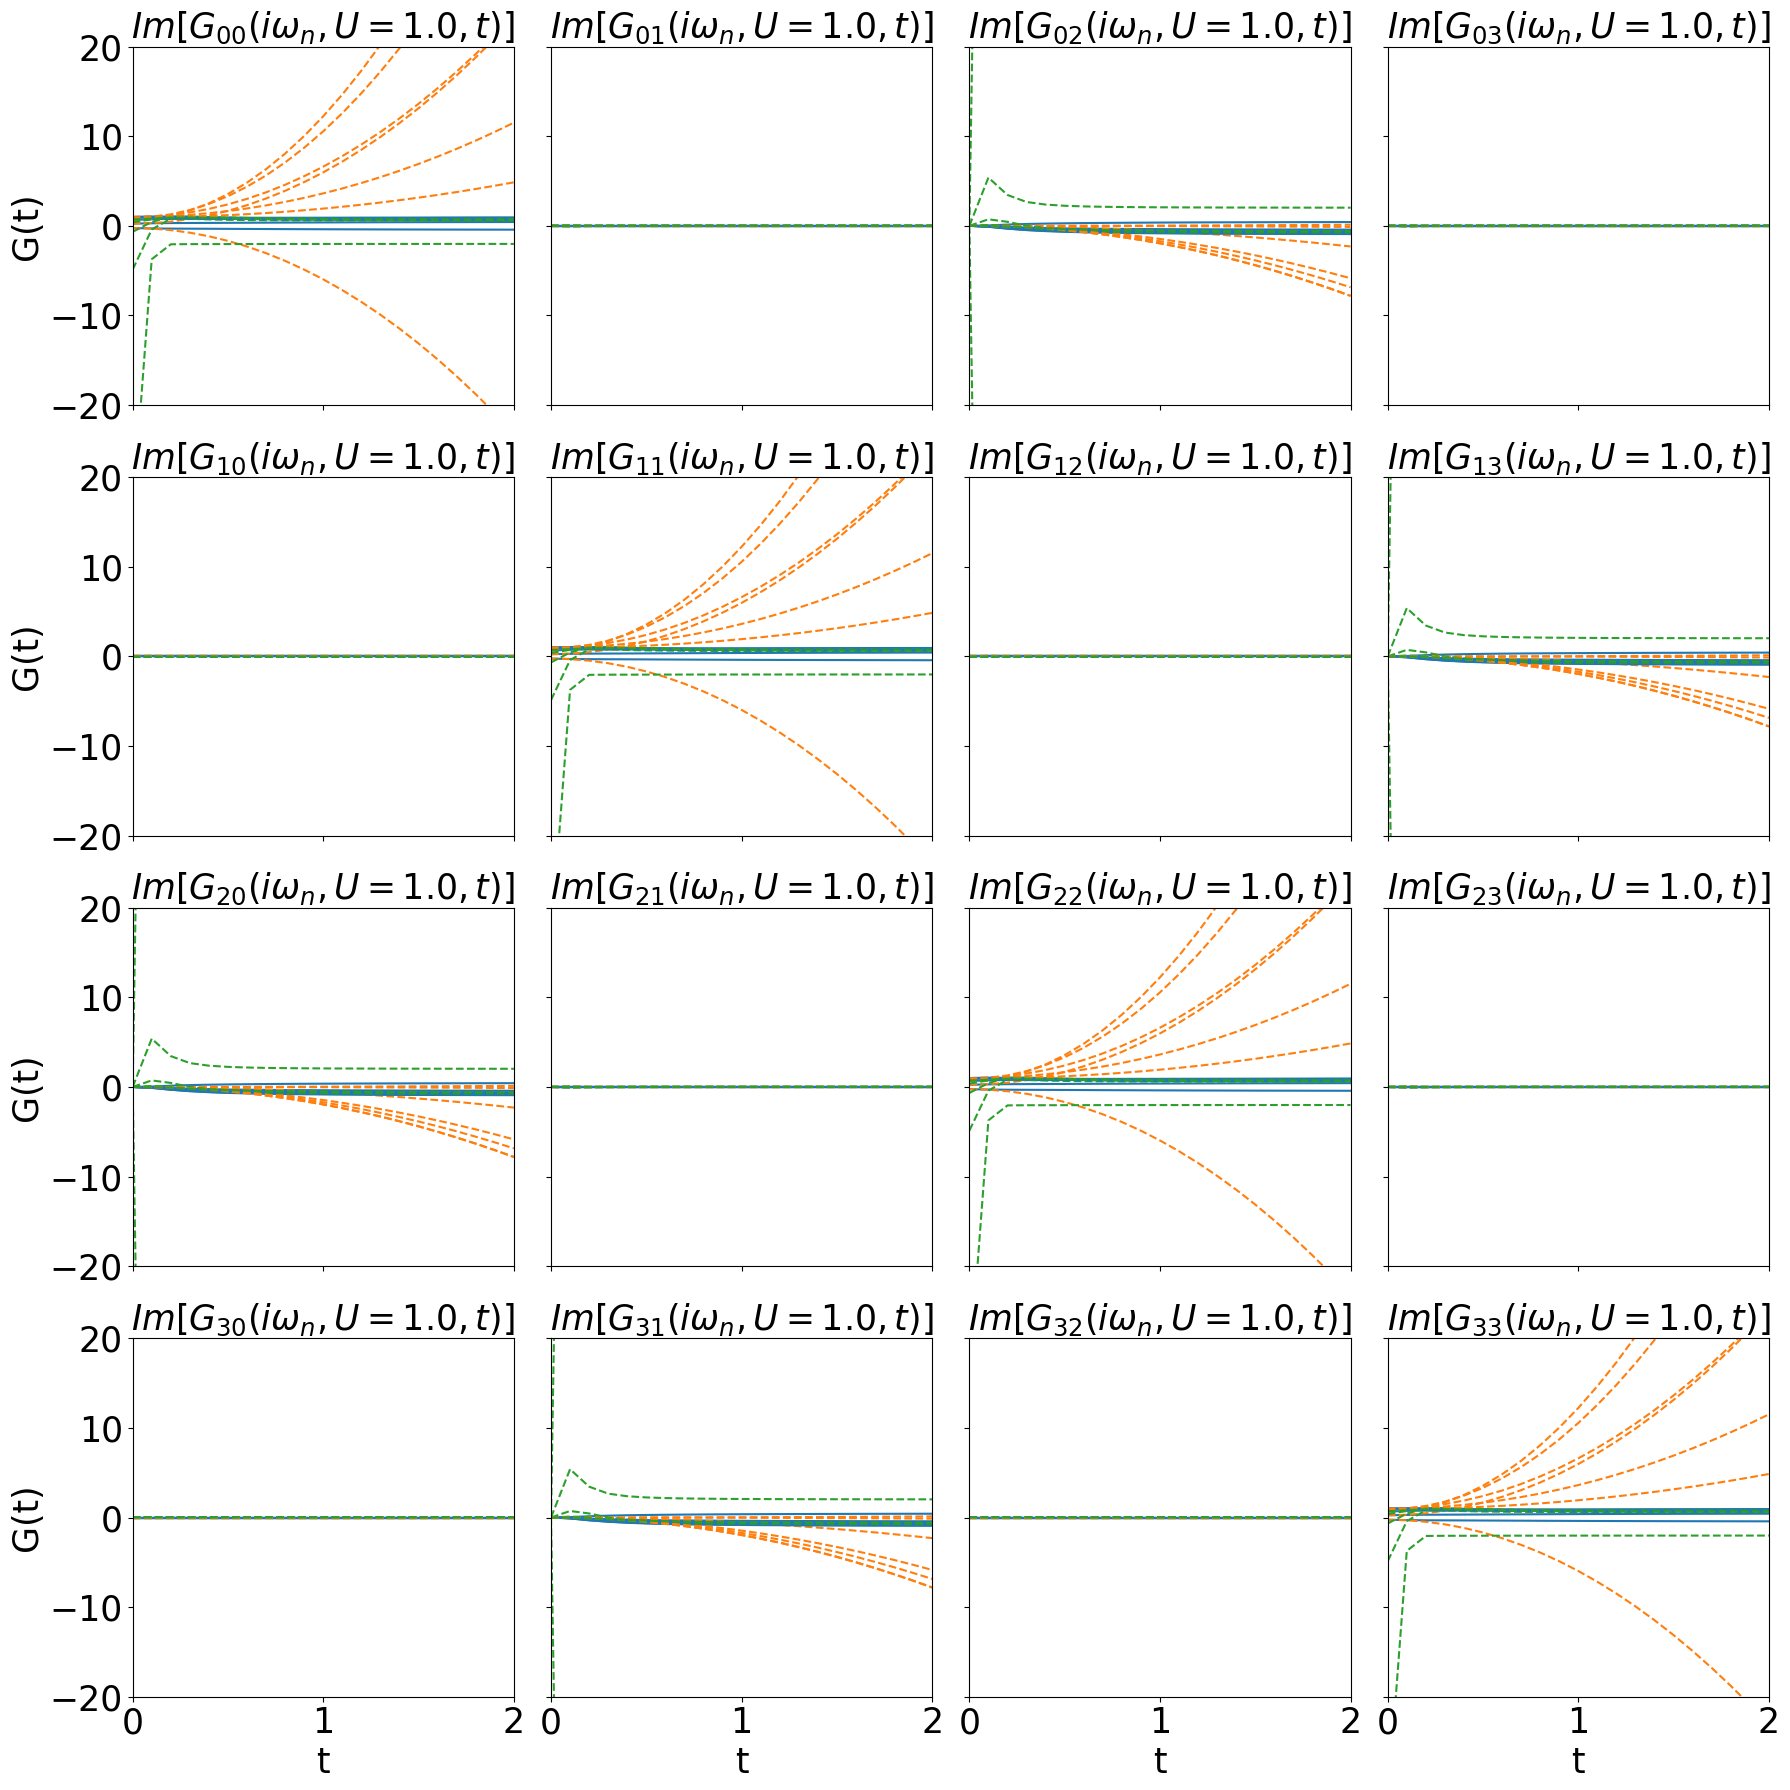

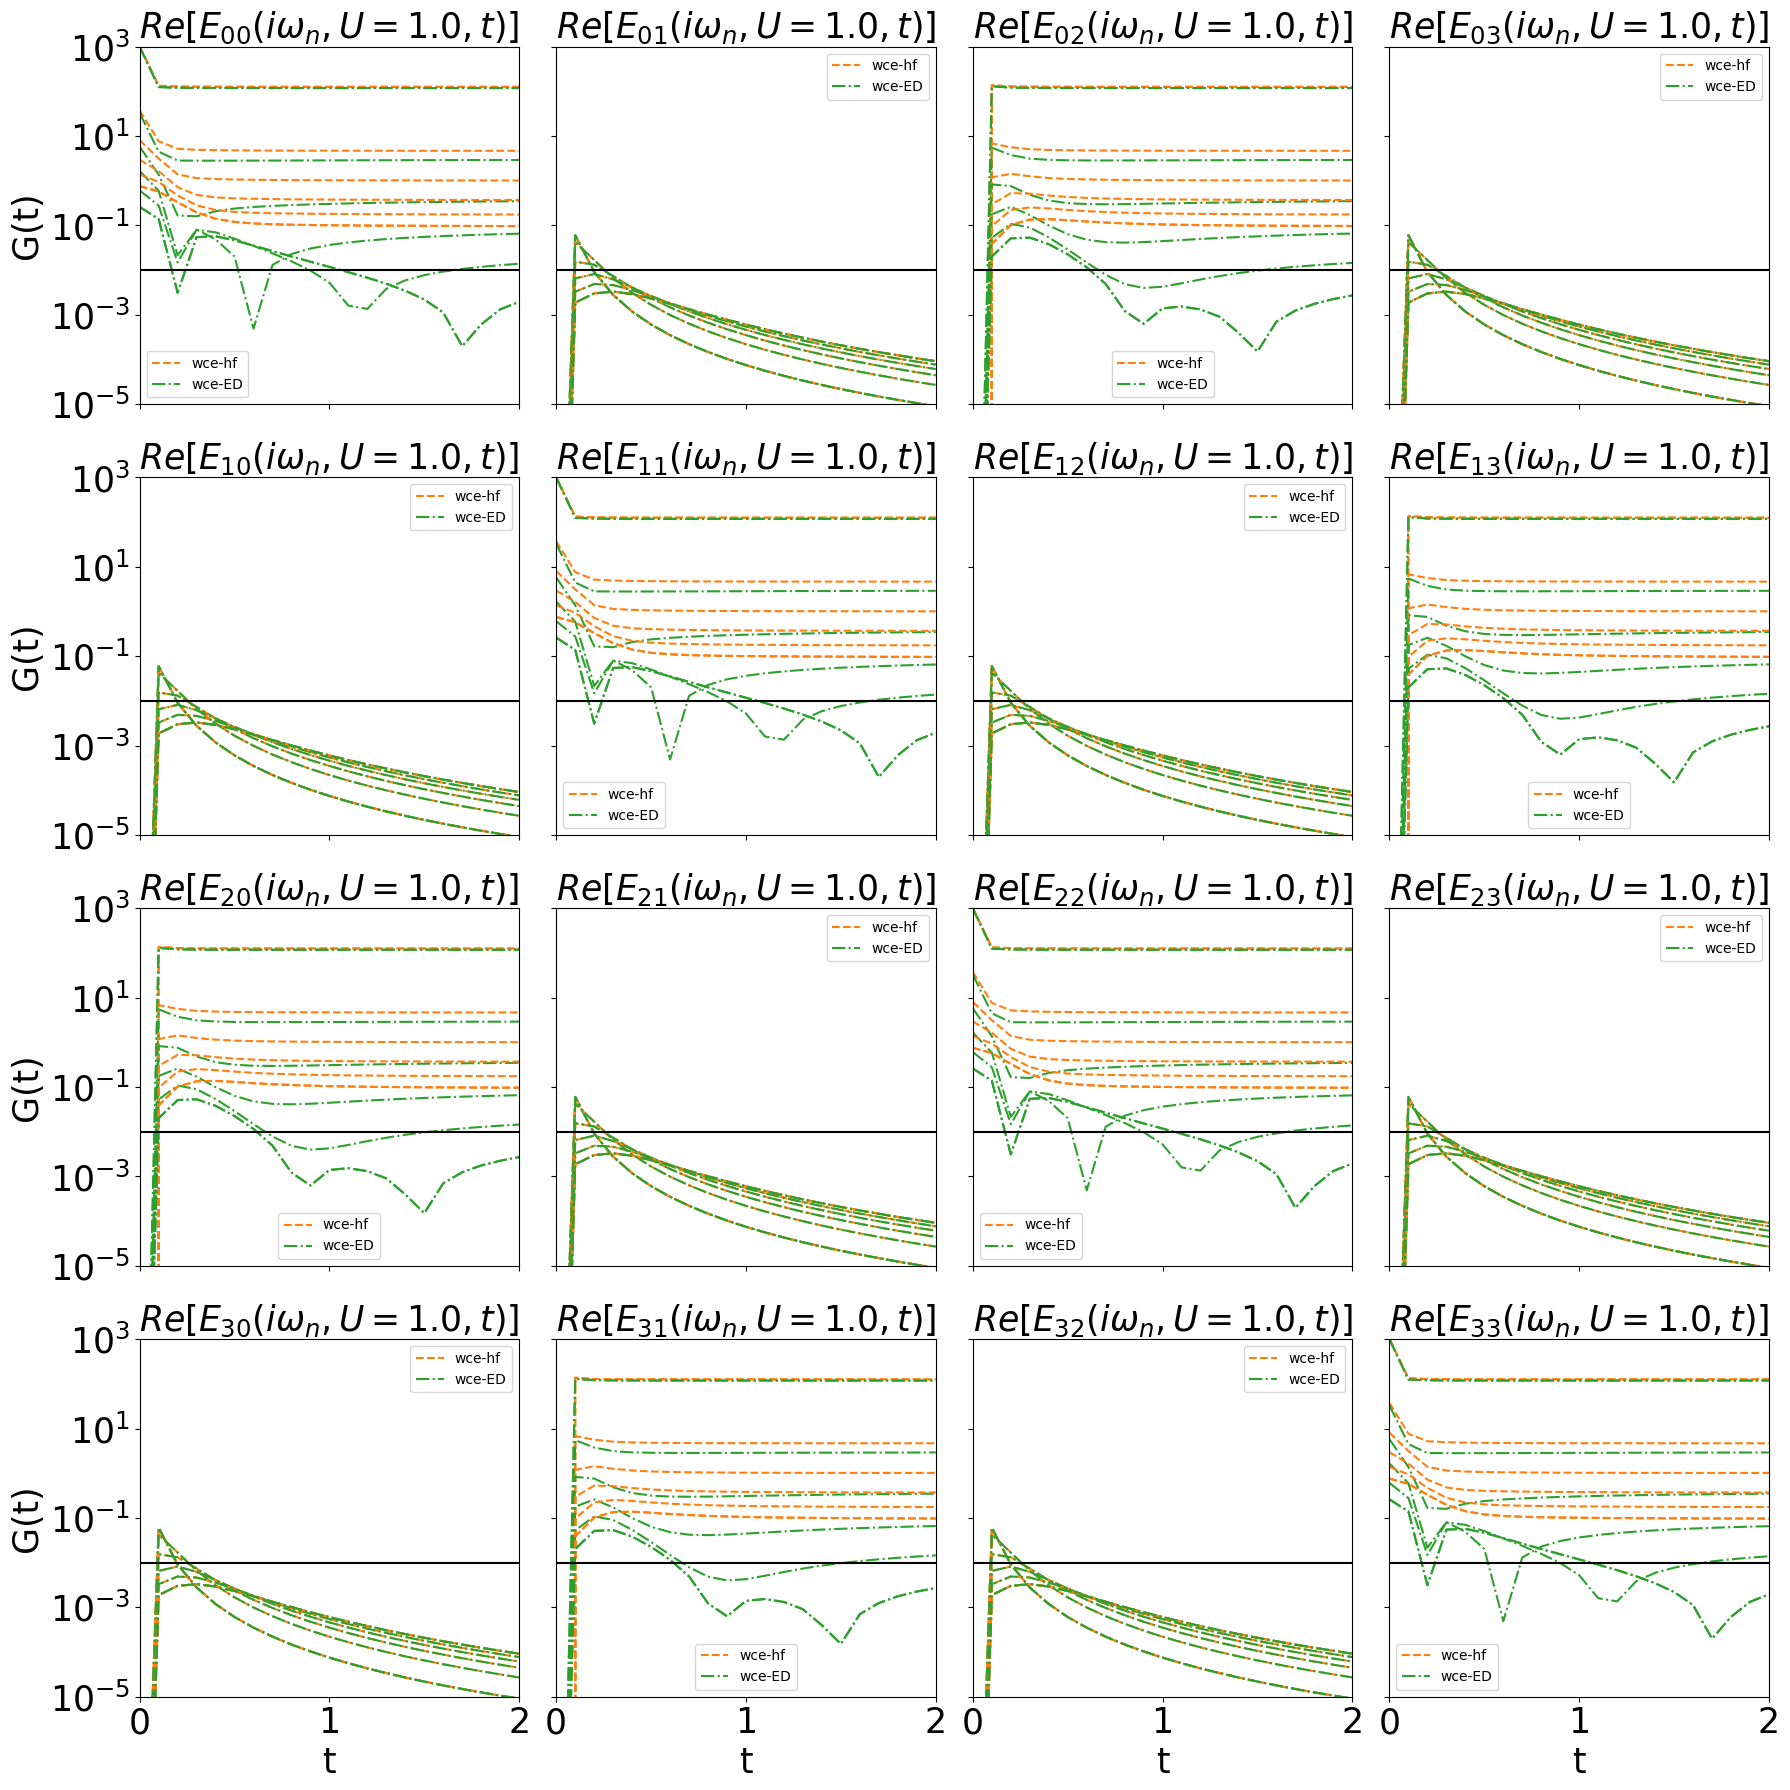

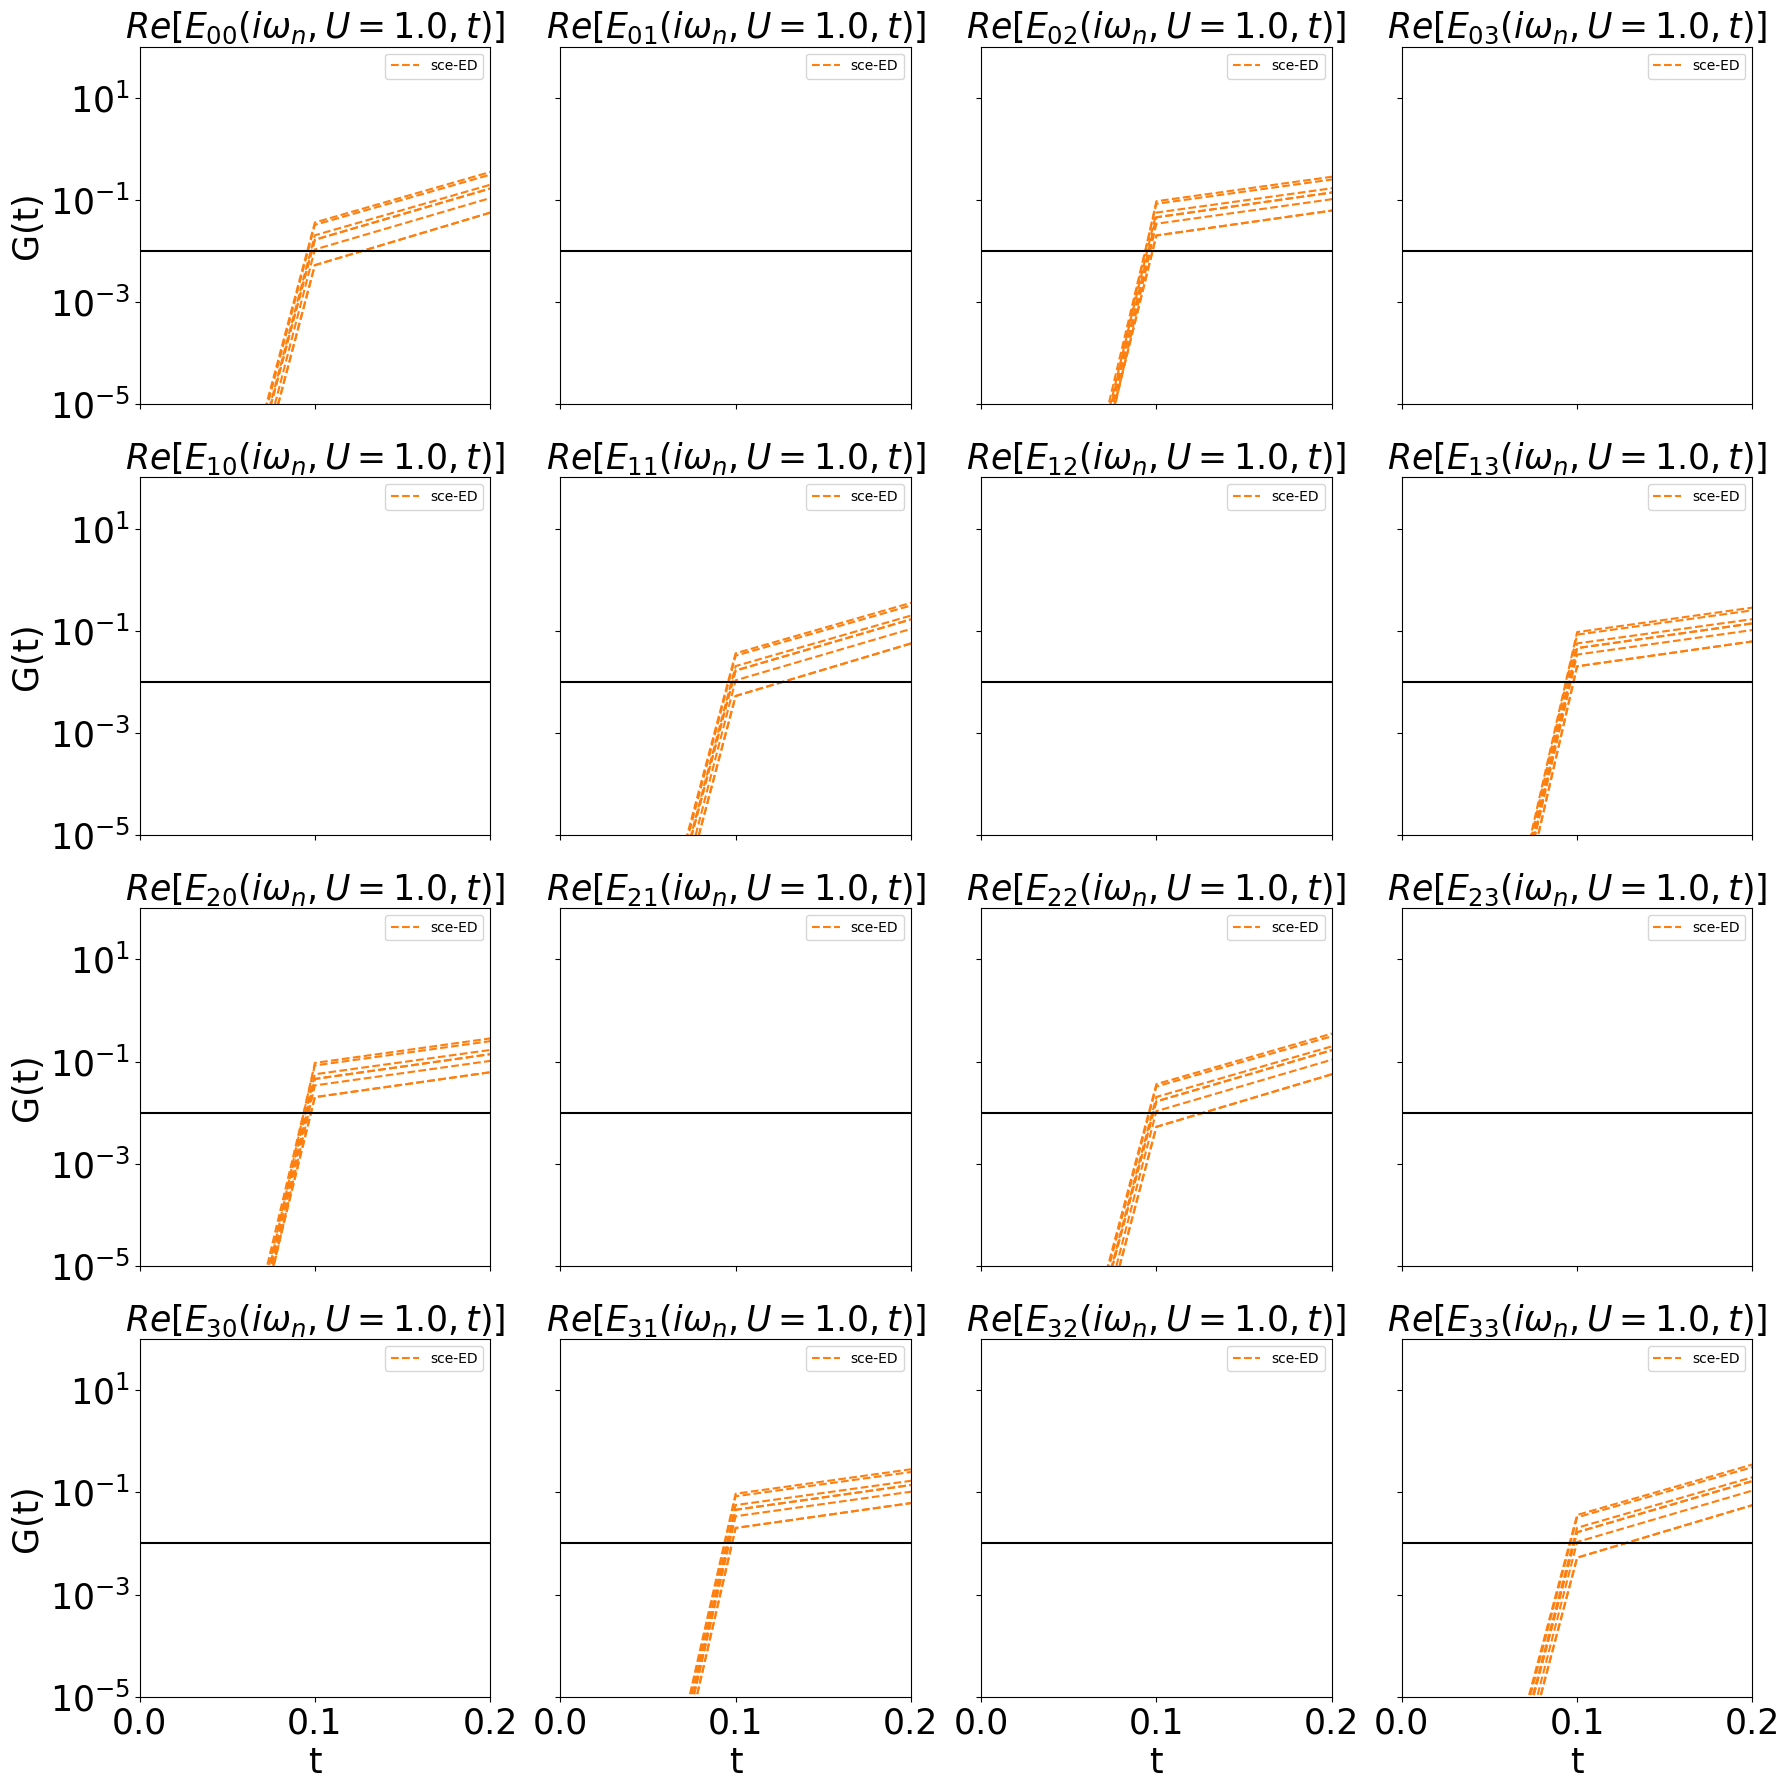

In [39]:
wn_id = [Nw, Nw-1, Nw-2, Nw-3, Nw-4, Nw-5, Nw-6]
print("tested wns are:", wn[wn_id])
# 
fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            ax.plot(t_values_ED, Gij_iwn_ED[:, k, i ,j ].imag, 'C0')
            ax.plot(t_values_sce, Gij_iwn_sce[:, k, i ,j ].imag, 'C1--')
            ax.plot(t_values_wce, Gij_iwn_wce[:, k, i ,j ].imag, 'C2--')
            # ax.plot(t_values_wce, Gij_iwn_hf[:, k, i ,j ].imag, 'C3--')
        ax.set_title(r'$Im[G_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([-20,20])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            # ax.semilogy(t_values_ED, np.abs(Gij_iwn_hf[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C0')
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].imag-Gij_iwn_hf[:, k, i ,j ].imag), 'C1--')
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C2-.')
        # ax.semilogy(t_values_ED, np.abs(Gij_iwn_hf[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C0', label ='HF-ED')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].imag-Gij_iwn_hf[:, k, i ,j ].imag), 'C1--', label ='wce-hf')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_wce[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C2-.', label ='wce-ED')
        ax.semilogy(t_values_ED, 1e-2+0*t_values_ED, 'k')
        ax.set_title(r'$Re[E_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,2])
            ax.set_ylim([1e-5,1000])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()



fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)

for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in wn_id:
            ax.semilogy(t_values_ED, np.abs(Gij_iwn_sce[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C1--')
        ax.semilogy(t_values_ED, np.abs(Gij_iwn_sce[:, k, i ,j ].imag-Gij_iwn_ED[:, k, i ,j ].imag), 'C1--', label ='sce-ED')
        ax.semilogy(t_values_ED, 1e-2+0*t_values_ED, 'k')
        ax.set_title(r'$Re[E_{%d%d}(i\omega_n,U=%.1f, t)]$'%(i,j,U_values_ED[0]), fontsize=25)
        ax.tick_params(labelsize=25)
        ax.legend()
        if i == Ns - 1:
            ax.set_xlabel("t", fontsize=25)
            ax.set_xlim([0,0.2])
            ax.set_ylim([1e-5,100])
        if j == 0:
            ax.set_ylabel("G(t)", fontsize=25)

plt.tight_layout()
plt.show()


In [18]:
Gij_tau_wce = np.zeros((t_values_wce.size, Ntau, Ns, Ns))
Gij_tau_hf = np.zeros((t_values_wce.size, Ntau, Ns, Ns))
for t in range(t_values_wce.size):
    Gij_tau_wce[t] = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_wce[t], wn, np.linspace(0,beta,Ntau), beta))
    Gij_tau_hf[t] = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_hf[t], wn, np.linspace(0,beta,Ntau), beta))

In [ ]:
fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)
t_id = [-1]
for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        for k in t_id:
            ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_ED[k, :, i ,j ], 'C0')
            ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_hf[k, :, i ,j ], 'C1--')
            ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_wce[k, :, i ,j ], 'C2--')  
        ax.set_title(r'$-G_{%d%d}(\tau, t=%.1f)]$'%(i,j, t_values_ED[t_id]), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns - 1:
            ax.set_xlabel(r"$\tau$", fontsize=25)
            ax.set_xlim([0,beta])
            ax.set_ylim([-1,1])
        if j == 0:
            ax.set_ylabel(r"$G(\tau)$", fontsize=25)

plt.tight_layout()
plt.show()


In [ ]:
Gij_iwn_test = G0_bare(Ns, wn, 0.2)
Gij_tau_test = np.real(wce.Gij_iwn_to_Gij_tau(Gij_iwn_test, wn, np.linspace(0,beta,Ntau), beta))
fig, axes = plt.subplots(Ns, Ns, figsize=(18, 18),sharex=True, sharey=True)
t_id = [40]
for i in range(Ns):
    for j in range(Ns):
        ax = axes[i, j]
        ax.plot(np.linspace(0,beta,Ntau), -Gij_tau_test[:, i ,j ], 'C0')
        ax.set_title(r'$-G_{%d%d}(\tau, U=%.1f)]$'%(i,j,0.2), fontsize=25)
        ax.tick_params(labelsize=25)

        if i == Ns - 1:
            ax.set_xlabel(r"$\tau$", fontsize=25)
            ax.set_xlim([0,beta])
            ax.set_ylim([-1,1])
        if j == 0:
            ax.set_ylabel(r"$G(\tau)$", fontsize=25)

plt.tight_layout()
plt.show()